# 9.1.1 从先验与观测到参数后验

## 学习目标与先修知识

区分先验（prior）、似然（likelihood）与预测，推导高斯共轭更新并核对归一化。

先修：第5.3章条件概率（conditional probability）与Bayes公式、第7.3章高斯更新、第8.2章二次目标。

## 具体问题

一组稳态读数可以来自同一个未知偏差，也可以来自每次都重新抽取的个体偏差。相同数字放进不同模型（model），得到的参数（parameter）不确定性是否相同？先限定“同一个未知偏差”的重复测量，再区分参数与未来读数。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

先只算精度。先验均值0 U、方差（variance）4 U²，两个读数为1、3 U，每次噪声方差2 U²。

In [2]:
precision = 1/4 + 2/2
print("后验方差 / U²：",1/precision)
print("后验均值 / U：",(0/4+(1+3)/2)/precision)

后验方差 / U²： 0.8
后验均值 / U： 1.6


## 模型假设

未知的稳态偏差 θ 在整个实验中固定，θ~N(m₀,v₀)，v₀>0。给定θ后，读数 yᵢ=θ+εᵢ，εᵢ 独立同分布（independent and identically distributed）于N(0,r)，r>0，且与θ独立。量以教学单位U记录，方差以U²记录。θ 表示相对参考值的偏差，可以为正或负；所有读数共享同一个 θ。

## 数学解释与推导

似然 $L(\theta)=p(y\mid\theta)$ 是固定观测（observation）后关于参数的函数，不是已经归一化的参数密度。后验（posterior）为
$$p(\theta\mid y)=\frac{L(\theta)p(\theta)}{Z},\qquad Z=\int L(\theta)p(\theta)\,d\theta,\quad 0<Z<\infty.$$
证据Z相对于本次观测是常数，因此找模态（mode）可暂时忽略它，计算概率（probability）却不能忽略归一化。高斯乘积的负对数（除去与θ无关项）为
$$\frac{(\theta-m_0)^2}{2v_0}+\sum_{i=1}^n\frac{(y_i-\theta)^2}{2r}
=\frac12\left(\frac1{v_0}+\frac nr\right)\theta^2-\left(\frac{m_0}{v_0}+\frac{\sum_i y_i}{r}\right)\theta+C.$$
配方可得 $v=(v_0^{-1}+nr^{-1})^{-1}$、$m=v(m_0/v_0+\sum_i y_i/r)$，所以后验是N(m,v)。这称为共轭先验（conjugate prior）：更新后的分布（distribution）仍属于同一家族，更新前后都用均值与方差描述。

本例最大后验估计（maximum a posteriori estimation，MAP）是m，同时等于后验均值；一般非对称后验不相等。n>0时极大似然估计是样本均值，它没有先验项。同一批数据再乘一次似然会错误地把n变成2n。

新读数 $y_{new}=\theta+\epsilon_{new}$，新噪声与已有信息及θ独立，因此预测分布为N(m,v+r)。多测几次让v变小，并不会使单次读数的噪声r消失。n=0时保留先验，预测方差仍为v₀+r。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def normal_update(prior_mean,prior_variance,observations,noise_variance):
    precision=1/prior_variance+len(observations)/noise_variance
    variance=1/precision
    mean=variance*(prior_mean/prior_variance+sum(observations)/noise_variance)
    return mean,variance,variance+noise_variance


def logsumexp(values):
    top=max(values)
    return top+math.log(sum(math.exp(x-top) for x in values))


def grid_posterior(nodes,log_values):
    # Trapezoidal integration: endpoint nodes receive half interval weights.
    widths=[(nodes[1]-nodes[0])/2]+[(nodes[i+1]-nodes[i-1])/2 for i in range(1,len(nodes)-1)]+[(nodes[-1]-nodes[-2])/2]
    log_mass=[l+math.log(w) for l,w in zip(log_values,widths)]
    normalizer=logsumexp(log_mass)
    weights=[math.exp(l-normalizer) for l in log_mass]
    mean=sum(w*x for w,x in zip(weights,nodes))
    variance=sum(w*(x-mean)**2 for w,x in zip(weights,nodes))
    return weights,mean,variance,normalizer


def normal_logpdf(value,mean,variance):
    return -.5*(math.log(2*math.pi*variance)+(value-mean)**2/variance)

## 对照实验

分别画出先验、后验和一个新读数的预测密度，再对比逐步加入同一实验的不同读数。曲线面积是概率，密度高度的单位为1/U。

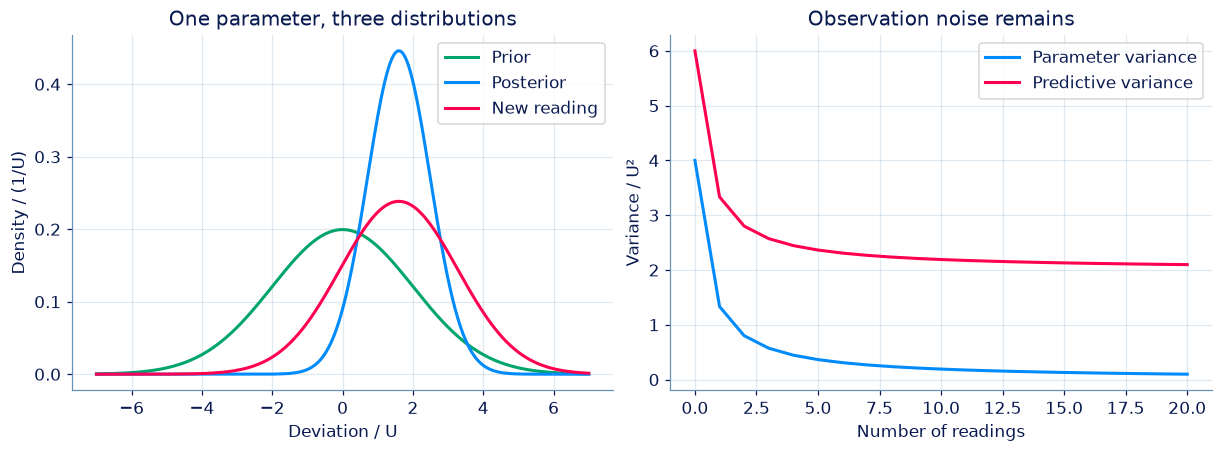

| 对象 | 均值 / U | 方差 / U² |
| --- | --- | --- |
| 参数后验 | 1.6 | 0.8 |
| 新读数 | 1.6 | 2.8 |

In [4]:
observed=[1.,3.];m,v,pv=normal_update(0.,4.,observed,2.)
x=np.linspace(-7,7,1001);fig,axes=plt.subplots(1,2,figsize=(11,4))
for mean,var,label,color in [(0,4,'Prior',GREEN),(m,v,'Posterior',BLUE),(m,pv,'New reading',PINK)]:
    axes[0].plot(x,np.exp([normal_logpdf(z,mean,var) for z in x]),label=label,color=color)
axes[0].set(xlabel='Deviation / U',ylabel='Density / (1/U)',title='One parameter, three distributions');axes[0].legend()
counts=np.arange(21);variances=[normal_update(0,4,[2.]*int(n),2)[1:] for n in counts]
axes[1].plot(counts,np.array(variances)[:,0],label='Parameter variance');axes[1].plot(counts,np.array(variances)[:,1],label='Predictive variance');axes[1].set(xlabel='Number of readings',ylabel='Variance / U²',title='Observation noise remains');axes[1].legend();plt.show()
display(Markdown(show_table(['对象','均值 / U','方差 / U²'],[('参数后验',m,v),('新读数',m,pv)])))

## 结果解释

本例后验均值1.6 U、方差0.8 U²，新读数方差2.8 U²。后验比先验集中，但预测密度比参数后验宽。右图固定每次读数为2只是隔离精度累积的条件实验，不能据此估计实际重复实验的覆盖率。先验越集中越能影响均值，也可能使错误先验下的后验集中在错误位置。

### 独立核对

独立地把先验密度与每个观测密度相乘，用梯形积分归一化，对照配方闭式；积分覆盖到±14 U并加密一次。

In [5]:
for count in [1401,2801]:
    nodes=np.linspace(-14,14,count)
    logs=[normal_logpdf(z,0,4)+sum(normal_logpdf(y,z,2) for y in observed) for z in nodes]
    weights,gm,gv,logZ=grid_posterior(nodes.tolist(),logs)
    np.testing.assert_allclose([gm,gv],[m,v],atol=1e-8)
    assert abs(sum(weights)-1)<1e-12
assert normal_update(3,2,[],1)==(3,2,3)
print('密度乘积积分、解析矩与空观测边界一致。')

密度乘积积分、解析矩与空观测边界一致。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/09-01-贝叶斯建模与后验近似/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：把读数变成参数后验

未知稳态偏差服从给定高斯先验（prior）；读数等于偏差加独立零均值高斯噪声。返回后验（posterior）均值、方差（variance）和一个新读数的预测方差。

**函数与代码模板**

```python
def solve(
    prior_mean: float,
    prior_variance: float,
    observations: list[float],
    noise_variance: float,
) -> tuple[float, float, float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `prior_mean` | `float` | 同一未知偏差的先验均值。 | U |
| `prior_variance` | `float` | 先验方差，大于零。 | U² |
| `observations` | `list[float]` | 对同一偏差的独立有噪读数，可为空。 | U |
| `noise_variance` | `float` | 每次观测（observation）已知且相同的噪声方差。 | U² |

**返回值**

按以下顺序返回元组：(mean, variance, predictive_variance)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `mean` | `float` | 更新后参数（parameter）均值。 | U |
| `variance` | `float` | 更新后参数方差。 | U² |
| `predictive_variance` | `float` | 同条件下一个新读数的预测方差。 | U² |

**计算规则**

v=1/(1/v0+n/r)，m=v(m0/v0+sum(y)/r)；预测方差v+r。空观测返回原先验与先验预测方差。

**约束与边界**

- 先验与噪声方差在[0.01,100]；0≤n≤100；各均值/读数绝对值≤100。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| prior_mean | 同一未知偏差的先验均值。 | 0 | U |
| prior_variance | 先验方差，大于零。 | 4 | U² |
| observations | 对同一偏差的独立有噪读数，可为空。 | [1.0, 3.0] | U |
| noise_variance | 每次观测（observation）已知且相同的噪声方差。 | 2 | U² |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
prior_mean = 0.0
prior_variance = 4.0
observations = [1.0, 3.0]
noise_variance = 2.0

result = solve(prior_mean, prior_variance, observations, noise_variance)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| mean | 更新后参数（parameter）均值。 | 1.6 | U |
| variance | 更新后参数方差。 | 0.8 | U² |
| predictive_variance | 同条件下一个新读数的预测方差。 | 2.8 | U² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (1.6, 0.8, 2.8)
```

**样例解释**

精度为1/4+2/2=1.25，后验均值1.6、方差0.8；新读数还含2单位噪声方差，预测方差为2.8。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：把读数变成参数后验](http://127.0.0.1:8000/chapters/09-01-%E8%B4%9D%E5%8F%B6%E6%96%AF%E5%BB%BA%E6%A8%A1%E4%B8%8E%E5%90%8E%E9%AA%8C%E8%BF%91%E4%BC%BC/practice/?question=p09-normal-update)

### 第 2 题 · 多项选择题：似然是在比较什么

固定已观察的读数y，考察L(θ)=p(y|θ)。哪些说法成立？

- **A.** 它是θ的概率密度（probability density），自动积分为1。
- **B.** 它用于比较不同θ对同一y的解释。
- **C.** 后验（posterior）归一化需要结合先验（prior）并计算证据。
- **D.** 可以在没有新增观测（observation）时反复乘同一似然（likelihood），增加独立信息。

[作答：似然是在比较什么](http://127.0.0.1:8000/chapters/09-01-%E8%B4%9D%E5%8F%B6%E6%96%AF%E5%BB%BA%E6%A8%A1%E4%B8%8E%E5%90%8E%E9%AA%8C%E8%BF%91%E4%BC%BC/practice/?question=p09-likelihood-object)

### 第 3 题 · 多项选择题：参数知道得更准以后

重复测量同一个稳定偏差，已知读数噪声方差（variance）r>0。读数很多时有哪些结论？

- **A.** 参数（parameter）方差可趋近0。
- **B.** 一个新读数的预测方差可趋近r。
- **C.** 未来读数必与后验（posterior）均值完全相等。
- **D.** 以上极限（limit）依赖同一偏差及独立噪声等模型（model）假设。

[作答：参数知道得更准以后](http://127.0.0.1:8000/chapters/09-01-%E8%B4%9D%E5%8F%B6%E6%96%AF%E5%BB%BA%E6%A8%A1%E4%B8%8E%E5%90%8E%E9%AA%8C%E8%BF%91%E4%BC%BC/practice/?question=p09-posterior-predictive)

### 第 4 题 · 单项选择题：先验强度怎样起作用

同一批读数下缩小高斯先验（prior）方差（variance），其他量不变。哪项正确？

- **A.** 后验（posterior）均值通常更靠近先验均值，但这不证明先验更真实。
- **B.** 数据的观测（observation）噪声自动变小。
- **C.** 后验变窄就证明模型（model）无偏。
- **D.** 先验选择不需要任何说明。

[作答：先验强度怎样起作用](http://127.0.0.1:8000/chapters/09-01-%E8%B4%9D%E5%8F%B6%E6%96%AF%E5%BB%BA%E6%A8%A1%E4%B8%8E%E5%90%8E%E9%AA%8C%E8%BF%91%E4%BC%BC/practice/?question=p09-prior-vs-data)

### 第 5 题 · 单项选择题：后验什么时候存在

先验（prior）密度p与似然（likelihood）L均非负。作为概率密度（probability density）的后验（posterior）还要求什么？

- **A.** 归一化积分Z满足0<Z<∞。
- **B.** 任何非负函数都自动可归一化。
- **C.** L为常数零也能得到后验。
- **D.** 采用不适定先验时无需再检查Z。

[作答：后验什么时候存在](http://127.0.0.1:8000/chapters/09-01-%E8%B4%9D%E5%8F%B6%E6%96%AF%E5%BB%BA%E6%A8%A1%E4%B8%8E%E5%90%8E%E9%AA%8C%E8%BF%91%E4%BC%BC/practice/?question=p09-normalizer-zero)

**进一步阅读**

[Murphy，Probabilistic Machine Learning: Advanced Topics](https://probml.github.io/pml-book/book2.html)：后验近似、采样与预测检验。